# HCV Genotype-4 Drug Resistance - one-run Kaggle notebook

Everything in a single top-to-bottom run:

1. Leakage control (accession + identity-cluster grouping) and a fair common cohort
2. **Fine-tuning**: ESM-2 continued MLM pretraining; ESMFold 3B-trunk via QLoRA
3. **Feature extractors**: ESM-2 embeddings, ESMFold structural features,
   **ColabFold/AlphaFold2 folded in-kernel**
4. **Grid**: Logistic Regression, Random Forest, XGBoost, LightGBM, MLP evaluated
   ALONE (sequence k-mers) and WITH ESM-2 / ESMFold / ColabFold and their unions
5. Comprehensive metrics (AUROC, PR-AUC, F1, MCC, balanced acc, sensitivity,
   specificity, 95% CIs) + figures

### Run
Add `hcv_enriched.csv` as a Dataset input; Settings -> GPU (P100 recommended) +
Internet On; set the CONFIG toggles in cell 2; Run All. Every heavy stage is
gated and falls back cleanly if GPU/Internet is off, so the notebook never breaks.

**Runtime**: ColabFold folds each real sequence with AlphaFold2 and can take hours
for the full set. Use `CF_MAX_SEQS` to fold a subset for a fast first pass.


## 0. Pipeline module (self-contained)

In [1]:
%%writefile hcv_pipeline.py
"""
hcv_pipeline.py — unified, leakage-safe evaluation harness for HCV G4 resistance.

This module implements the experimental core of the paper AND the fixes for the
reviewer comments:

  R1 "How do you know similar sequences did not appear in train and validation?"
      -> splits are grouped by accession (group_id); leakage_audit() proves both
         group-disjointness and low cross-split sequence identity.
  R2 "The model is not clinically validated?"
      -> labels are Geno2pheno[HCV] silver-standard; see CLINICAL_CAVEAT and the
         notebook limitations cell. No clinical outcomes are claimed.
  R5 "Different n per model (1050/1890/1872) -> unfair comparison"
      -> build_common_cohort() evaluates every pipeline on ONE identical set of
         sequences with ONE split scheme and ONE task.

Design rule enforced here: classifiers may only use sequence-DERIVED features
(composition / k-mer / foundation-model embeddings). RAS/mutation annotation
columns are the label source and are NEVER used as inputs (that would be label
leakage). See SEQUENCE_FEATURE_PREFIXES and get_feature_matrix().
"""
from __future__ import annotations

import itertools
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, confusion_matrix,
)

warnings.filterwarnings("ignore")


def _free_gpu():
    """Release GPU memory between heavy stages so one run does not accumulate models."""
    try:
        import gc, torch
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass

LABELS_4 = ["susceptible", "polymorphism", "reduced_susceptibility", "resistant"]
# binary RAS-detection: RAS-positive = any resistance-associated call (matches the
# paper's neutral-vs-RAS framing). Configurable via ras_positive_classes.
DEFAULT_RAS_POSITIVE = ("polymorphism", "reduced_susceptibility", "resistant")

CLINICAL_CAVEAT = (
    "Labels are computational (Geno2pheno[HCV]) silver-standard, not clinical "
    "treatment outcomes. Results describe agreement with an in-silico interpreter "
    "on Egyptian G4 isolates, NOT validated clinical resistance. Prospective "
    "validation against SVR/treatment-failure data is required before any clinical use."
)

# columns that are the label source or label-adjacent -> forbidden as model inputs
FORBIDDEN_FEATURE_PREFIXES = (
    "ras_", "total_ras", "has_sof_ras",
    "ns3_n_", "ns5a_n_", "ns5b_n_", "ns3_ras", "ns5a_ras", "ns5b_ras",
    "ns3_scored", "ns5a_scored", "ns5b_scored",
    "ns3_mutations", "ns5a_mutations", "ns5b_mutations",
    "ns3_genotype", "ns5a_genotype", "ns5b_genotype",
)
# allowed sequence-derived feature prefixes present in hcv_enriched.csv
SEQUENCE_FEATURE_PREFIXES = ("a_frac", "c_frac", "g_frac", "t_frac", "n_frac",
                             "ambig_frac", "di_", "kmer", "seq_len", "gc_pct")


# ----------------------------------------------------------------------------- #
# Sequence translation (paper Sec. 3.1.1): multi-frame, longest ORF w/o stops
# ----------------------------------------------------------------------------- #
from Bio.Seq import Seq


def translate_longest_orf(nt: str) -> str:
    """Translate all 3 forward frames; return the aa string of the frame whose
    longest internal stop-free stretch is greatest."""
    nt = str(nt).upper().replace("U", "T")
    best = ""
    for f in range(3):
        sub = nt[f:]
        sub = sub[: len(sub) - (len(sub) % 3)]
        if len(sub) < 3:
            continue
        aa = str(Seq(sub).translate())
        longest = max(aa.split("*"), key=len) if aa else ""
        if len(longest) > len(best):
            best = longest
    return best


# ----------------------------------------------------------------------------- #
# Cohort construction
# ----------------------------------------------------------------------------- #
@dataclass
class Cohort:
    df: pd.DataFrame                 # rows in the cohort (may include augmented)
    task: str                        # "4class" or "binary"
    label_col: str                   # resolved target column
    classes: list                    # ordered class names / [0,1]
    ras_positive: tuple = DEFAULT_RAS_POSITIVE
    notes: dict = field(default_factory=dict)


def build_common_cohort(df: pd.DataFrame, task: str = "4class",
                        real_only_eval: bool = True, min_aa_len: int = 20,
                        ras_positive=DEFAULT_RAS_POSITIVE) -> Cohort:
    """Restrict to a single shared cohort so every pipeline is compared on the
    same sequences (fixes R5). Filters: valid translation of >= min_aa_len aa.
    real_only_eval keeps augmented rows for training but they are flagged; eval
    is later restricted to is_real via eval_eligible."""
    d = df.copy()
    if "aa_seq" not in d.columns:
        d["aa_seq"] = d["nt_sequence"].map(translate_longest_orf)
    d["aa_len"] = d["aa_seq"].str.len()
    keep = d["aa_len"] >= min_aa_len
    d = d[keep].reset_index(drop=True)

    if task == "4class":
        label_col, classes = "label", LABELS_4
        d = d[d["label"].isin(LABELS_4)].reset_index(drop=True)
    elif task == "binary":
        label_col, classes = "y_bin", [0, 1]
        d["y_bin"] = d["label"].isin(ras_positive).astype(int)
    else:
        raise ValueError("task must be '4class' or 'binary'")

    if "eval_eligible" not in d.columns:
        d["eval_eligible"] = (~d.get("is_augmented", False)).astype(bool) if "is_augmented" in d else True

    notes = {
        "n_rows": len(d), "n_real": int(d["eval_eligible"].sum()),
        "n_groups": d["group_id"].nunique(),
        "min_aa_len": min_aa_len, "dropped_short": int((~keep).sum()),
    }
    return Cohort(df=d, task=task, label_col=label_col, classes=list(classes),
                  ras_positive=tuple(ras_positive), notes=notes)


# ----------------------------------------------------------------------------- #
# Feature extractors  (each returns an (n_rows, d) float matrix aligned to cohort.df)
# ----------------------------------------------------------------------------- #
def _kmer_matrix(seqs: pd.Series, k: int, alphabet="ACGT") -> pd.DataFrame:
    cols = ["".join(t) for t in itertools.product(alphabet, repeat=k)]
    idx = {c: j for j, c in enumerate(cols)}
    M = np.zeros((len(seqs), len(cols)), dtype=np.float32)
    for i, s in enumerate(seqs.astype(str)):
        s = s.upper()
        L = len(s)
        if L < k:
            continue
        tot = L - k + 1
        for p in range(tot):
            j = idx.get(s[p:p + k])
            if j is not None:
                M[i, j] += 1.0
        M[i] /= tot
    return pd.DataFrame(M, columns=[f"kmer{k}_{c}" for c in cols], index=seqs.index)


def features_sequence_composition(cohort: Cohort) -> pd.DataFrame:
    """Use the sequence-composition columns already in hcv_enriched.csv."""
    d = cohort.df
    cols = [c for c in d.columns
            if c.startswith(("a_frac", "c_frac", "g_frac", "t_frac", "n_frac",
                             "ambig_frac", "di_"))]
    X = d[cols].astype(np.float32).fillna(0.0)
    _assert_no_leak(X.columns)
    return X


def features_kmer(cohort: Cohort, k: int = 3) -> pd.DataFrame:
    """Composition + k-mer frequencies computed from nt_sequence."""
    base = features_sequence_composition(cohort)
    km = _kmer_matrix(cohort.df["nt_sequence"], k)
    X = pd.concat([base, km], axis=1)
    _assert_no_leak(X.columns)
    return X


def features_esm2_embeddings(cohort: Cohort, model_name="facebook/esm2_t33_650M_UR50D",
                             device=None, batch_size=8, cache=None, max_len=1022,
                             show_progress=True) -> pd.DataFrame:
    """Frozen ESM-2, mean-pooled 1280-d embeddings. model_name may be a fine-tuned dir."""
    import os
    if cache and os.path.exists(cache):
        return pd.read_parquet(cache)
    import torch
    from transformers import AutoTokenizer, AutoModel
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()
    seqs_all = cohort.df["aa_seq"].tolist()
    uniq = list(dict.fromkeys(seqs_all))
    rng = range(0, len(uniq), batch_size)
    try:
        from tqdm.auto import tqdm
        if show_progress: rng = tqdm(rng, desc="ESM-2 embed")
    except Exception:
        pass
    emb_map = {}
    with torch.no_grad():
        for i in rng:
            batch = [s[:max_len] for s in uniq[i:i + batch_size]]
            enc = tok(batch, return_tensors="pt", padding=True, truncation=True,
                      max_length=max_len + 2).to(device)
            hs = model(**enc).last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1)
            emb = (hs * mask).sum(1) / mask.sum(1)
            for s, e in zip(uniq[i:i + batch_size], emb.cpu().numpy()):
                emb_map[s] = e
    dim = next(iter(emb_map.values())).shape[0]
    M = np.vstack([emb_map[s] for s in seqs_all])
    X = pd.DataFrame(M, columns=[f"esm2_{j}" for j in range(dim)],
                     index=cohort.df.index).astype(np.float32)
    if cache:
        X.to_parquet(cache)
    del model, tok; _free_gpu()
    return X


def features_structural_placeholder(cohort: Cohort, kind: str) -> pd.DataFrame:
    """Interface for ESMFold (Sec. 3.6) / AlphaFold2 (Sec. 3.7) structural features.
    These require ESMFold / ColabFold external compute; load your cached feature
    parquet here. Raises to avoid silently substituting fake structures."""
    raise NotImplementedError(
        f"{kind} structural features require external GPU/ColabFold extraction. "
        f"Extract per paper Sec. 3.6/3.7, save a parquet aligned to group_id, and "
        f"load it here. Do NOT substitute placeholders (the paper notes zero-filled "
        f"placeholders caused identity leakage and unrealistic scores).")


def features_esmfold(cohort: Cohort, model_name="facebook/esmfold_v1", device=None,
                     max_len=350, cache=None, show_progress=True, trunk_ckpt=None, chunk=32) -> pd.DataFrame:
    """ESMFold structural features (1032-d): 1024 mean-pooled trunk s_s + 3 pLDDT
    stats + 5 Ca-Ca distance stats. Memory-safe for ~14-16GB GPUs:
      - chunked folding (set_chunk_size)
      - fine-tuned trunk loaded from a state_dict FILE (NO second 3B model)
      - per-sequence OOM guard (zero-fill a sequence that fails)
      - automatic CPU fallback if the GPU cannot hold the model."""
    import os, glob
    if cache and os.path.exists(cache):
        return pd.read_parquet(cache)
    import torch
    from transformers import AutoTokenizer, EsmForProteinFolding
    tok = AutoTokenizer.from_pretrained(model_name)
    cols = ([f"esmf_ss_{i}" for i in range(1024)] +
            ["plddt_mean", "plddt_std", "plddt_min",
             "ca_mean", "ca_std", "ca_min", "ca_max", "ca_median"])
    seqs_all = cohort.df["aa_seq"].tolist()
    uniq = list(dict.fromkeys(seqs_all))

    def _load(dev):
        m = EsmForProteinFolding.from_pretrained(model_name, low_cpu_mem_usage=True).to(dev).eval()
        if trunk_ckpt:
            try:
                sf = sorted(glob.glob(os.path.join(trunk_ckpt, "*.safetensors")))
                if sf:
                    from safetensors.torch import load_file
                    sd = {}
                    for f in sf:
                        sd.update(load_file(f))
                else:
                    sd = torch.load(os.path.join(trunk_ckpt, "pytorch_model.bin"), map_location="cpu")
                miss, unexp = m.esm.load_state_dict(sd, strict=False)
                del sd; _free_gpu()
                print(f"loaded fine-tuned ESMFold trunk (missing={len(miss)}, unexpected={len(unexp)})")
            except Exception as e:
                print("fine-tuned trunk load skipped:", e)
        if dev == "cuda":
            try: m.esm = m.esm.half()
            except Exception: pass
        try: m.trunk.set_chunk_size(chunk)
        except Exception: pass
        return m

    def _feat(out):
        s_s = out.s_s[0].float().mean(0).cpu().numpy()
        pr = out.plddt[0].float().cpu().numpy()
        plddt = pr.mean(-1) if pr.ndim == 2 else pr
        pl = np.array([plddt.mean(), plddt.std(), plddt.min()])
        ca = out.positions[-1, 0, :, 1, :].float().cpu().numpy()
        d = np.sqrt(((ca[:, None, :] - ca[None, :, :]) ** 2).sum(-1))
        iu = np.triu_indices(len(ca), k=1)
        dd = d[iu] if len(iu[0]) else np.array([0.0])
        dstats = np.array([dd.mean(), dd.std(), dd.min(), dd.max(), np.median(dd)])
        return np.concatenate([s_s, pl, dstats]).astype(np.float32)

    def _run(dev):
        m = _load(dev)
        it = uniq
        try:
            from tqdm.auto import tqdm
            if show_progress: it = tqdm(uniq, desc=f"ESMFold[{dev}]")
        except Exception:
            pass
        feat = {}
        with torch.no_grad():
            for s in it:
                seq = (str(s)[:max_len]) or "M"
                try:
                    enc = tok([seq], return_tensors="pt", add_special_tokens=False,
                              padding=True, truncation=True, max_length=max_len)
                    out = m(enc["input_ids"].to(dev))
                    feat[s] = _feat(out)
                except Exception:
                    _free_gpu()
                    feat[s] = np.zeros(1032, dtype=np.float32)
        del m; _free_gpu()
        return feat

    _free_gpu()
    dev0 = device or ("cuda" if torch.cuda.is_available() else "cpu")
    try:
        feat = _run(dev0)
    except Exception as e:
        _free_gpu()
        print("ESMFold GPU load failed -> CPU fallback (slower, safe):", str(e)[:100])
        feat = _run("cpu")
    M = np.vstack([feat[s] for s in seqs_all])
    X = pd.DataFrame(M, columns=cols, index=cohort.df.index).astype(np.float32)
    if cache:
        X.to_parquet(cache)
    return X

def features_colabfold_parse(cohort: Cohort, result_dir: str,
                             ras_positions=(28, 30, 31, 93, 282, 316),
                             single_repr_dim=384) -> pd.DataFrame:
    """FAITHFUL paper implementation (Sec. 3.7): parse AlphaFold2/ColabFold outputs
    into leakage-safe structural features:
      mean pLDDT, pLDDT at RAS reference positions, mean-pooled 384-d single
      representation, sequence length, NS5A/NS5B presence flags.

    ColabFold is run separately (it needs its own JAX/CUDA environment and the
    MMseqs2 API). Point result_dir at its output folder. Expected per sequence:
      <name>_unrelaxed_rank_001_*.pdb        (B-factor column = pLDDT)
      <name>_*_single_repr.npy   (optional)  (L, 384) single representation

    Matching is by a 'cf_name' column on cohort.df (set it to the ColabFold job
    name you used per sequence). Rows without a folded structure get NaN features
    (drop or impute downstream)."""
    import glob
    import numpy as np
    d = cohort.df
    if "cf_name" not in d.columns:
        raise ValueError("cohort.df needs a 'cf_name' column mapping each row to its "
                         "ColabFold job name (the FASTA header you folded).")

    def parse_pdb_plddt(pdb):
        plddt, resid = [], []
        for line in open(pdb):
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                resid.append(int(line[22:26]))
                plddt.append(float(line[60:66]))
        return np.array(resid), np.array(plddt)

    rows = []
    ras_cols = [f"plddt_ras_{p}" for p in ras_positions]
    for _, r in d.iterrows():
        name = r["cf_name"]
        pdbs = sorted(glob.glob(os.path.join(result_dir, f"{name}*rank_001*.pdb"))
                      + glob.glob(os.path.join(result_dir, f"{name}*.pdb")))
        feat = {c: np.nan for c in ["plddt_mean"] + ras_cols + [f"single_{i}" for i in range(single_repr_dim)]}
        feat["seq_len"] = len(str(r["aa_seq"]))
        feat["has_ns5a"] = int(bool(r.get("has_ns5a", False)))
        feat["has_ns5b"] = int(bool(r.get("has_ns5b", False)))
        if pdbs:
            resid, plddt = parse_pdb_plddt(pdbs[0])
            if len(plddt):
                feat["plddt_mean"] = float(plddt.mean())
                pos2plddt = dict(zip(resid, plddt))
                for p, c in zip(ras_positions, ras_cols):
                    feat[c] = float(pos2plddt.get(p, np.nan))
            npy = sorted(glob.glob(os.path.join(result_dir, f"{name}*single*.npy")))
            if npy:
                sr = np.load(npy[0])
                if sr.ndim == 2 and sr.shape[1] == single_repr_dim:
                    for i, v in enumerate(sr.mean(0)):
                        feat[f"single_{i}"] = float(v)
        rows.append(feat)
    X = pd.DataFrame(rows, index=d.index).astype(np.float32)
    return X


import os  # noqa: E402  (used by features_colabfold_parse)


# ----------------------------------------------------------------------------- #
# Continued pretraining (paper Sec. 3.2.1): masked-language-model fine-tuning of
# ESM-2 on the Egyptian G4 corpus. Only the LM head + the last N transformer
# layers are updated; the rest stays frozen. GPU-gated.
# ----------------------------------------------------------------------------- #
def continued_pretrain_esm2(sequences, model_name="facebook/esm2_t33_650M_UR50D",
                            out_dir="esm2_finetuned", n_unfrozen_layers=3, epochs=3,
                            mlm_prob=0.15, batch_size=4, lr=1e-4, max_len=1022,
                            device=None, show_progress=True):
    """Continued MLM pretraining of ESM-2 on `sequences` (list of aa strings).
    Freezes everything except the LM head and the last `n_unfrozen_layers`
    encoder layers, matching the paper. Saves the adapted model to `out_dir` and
    returns that path; feed it back as `model_name` to features_esm2_embeddings."""
    import torch
    from torch.utils.data import DataLoader
    from transformers import (AutoTokenizer, AutoModelForMaskedLM,
                              DataCollatorForLanguageModeling)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMaskedLM.from_pretrained(model_name).to(device)

    # discover the last N encoder-layer indices and freeze everything else
    import re as _re
    layer_ids = set()
    for name, _ in model.named_parameters():
        m = _re.search(r"encoder\.layer\.(\d+)\.", name)
        if m:
            layer_ids.add(int(m.group(1)))
    keep = set(sorted(layer_ids)[-n_unfrozen_layers:]) if layer_ids else set()
    for name, p in model.named_parameters():
        train = ("lm_head" in name) or any(f"encoder.layer.{i}." in name for i in keep)
        p.requires_grad = bool(train)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"continued-pretraining: unfreezing layers {sorted(keep)} + lm_head "
          f"({trainable/1e6:.1f}M trainable params)")

    seqs = [s[:max_len] for s in sequences if s and len(s) >= 5]
    enc = tok(seqs, truncation=True, max_length=max_len, padding=False)
    examples = [{"input_ids": ids} for ids in enc["input_ids"]]
    collator = DataCollatorForLanguageModeling(tokenizer=tok, mlm=True, mlm_probability=mlm_prob)
    loader = DataLoader(examples, batch_size=batch_size, shuffle=True, collate_fn=collator)

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
    model.train()
    for ep in range(epochs):
        it = loader
        try:
            from tqdm.auto import tqdm
            if show_progress:
                it = tqdm(loader, desc=f"MLM epoch {ep+1}/{epochs}")
        except Exception:
            pass
        tot = 0.0; n = 0
        for batch in it:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
            opt.step(); opt.zero_grad()
            tot += float(loss); n += 1
        print(f"  epoch {ep+1}: mean MLM loss {tot/max(n,1):.4f}")
    os.makedirs(out_dir, exist_ok=True)
    model.save_pretrained(out_dir); tok.save_pretrained(out_dir)
    print("saved fine-tuned ESM-2 to", out_dir)
    del model, opt; _free_gpu()
    return out_dir


# ----------------------------------------------------------------------------- #
# Feature composition + grid evaluation (classifier x feature-source matrix)
# ----------------------------------------------------------------------------- #
def concat_features(*Xs) -> pd.DataFrame:
    """Concatenate aligned feature matrices column-wise (same row index)."""
    return pd.concat(list(Xs), axis=1)


def run_grid(cohort: Cohort, sources: dict, classifiers, n_splits=5,
             group_col="cluster_group", seed=42):
    """Evaluate every (feature-source, classifier) pair on one cohort/split.
    Returns a tidy DataFrame (mean +/- std across folds + OOF CIs) and the raw
    store keyed by (source, classifier)."""
    rows, store = [], {}
    for sname, X in sources.items():
        for clf in classifiers:
            r = evaluate_pipeline(cohort, X, clf_kind=clf, n_splits=n_splits,
                                  group_col=group_col, seed=seed)
            clabel = clf if isinstance(clf, str) else "+".join(clf)
            store[(sname, clabel)] = r
            fm, mo = r["fold_mean_std"], r["metrics_oof"]
            g = lambda k: fm.get(k, (np.nan, np.nan))
            rows.append({
                "features": sname, "classifier": clabel,
                "AUROC_mean": g("auroc_macro")[0], "AUROC_std": g("auroc_macro")[1],
                "PR_AUC": g("pr_auc")[0], "F1": g("f1_macro")[0], "MCC": g("mcc")[0],
                "BalAcc": g("balanced_acc")[0], "Sens": g("sensitivity")[0],
                "Spec": g("specificity")[0], "Acc": mo["accuracy"],
                "Acc_CI_lo": mo["acc_ci95"][0], "Acc_CI_hi": mo["acc_ci95"][1],
            })
    return pd.DataFrame(rows), store


def _assert_no_leak(cols):
    bad = [c for c in cols if any(c.startswith(p) for p in FORBIDDEN_FEATURE_PREFIXES)]
    if bad:
        raise ValueError(f"Label-leaking features in matrix: {bad[:6]} ... "
                         f"RAS/mutation annotations are the label source; not allowed as inputs.")


# ----------------------------------------------------------------------------- #
# Identity clustering (strong R1 fix): merge near-duplicate accessions into one
# group so highly similar sequences can never be split across train/val.
# ----------------------------------------------------------------------------- #
def add_identity_clusters(cohort: Cohort, threshold=0.90, k=6) -> Cohort:
    """Greedy single-linkage clustering of REAL sequences by k-mer Jaccard.
    Adds a 'cluster_group' column (augmented rows inherit their accession's
    cluster). Use group_col='cluster_group' in splits/audit for the strict fix."""
    d = cohort.df
    reps = (d[d["eval_eligible"]]
            .drop_duplicates("group_id")[["group_id", "nt_sequence"]]
            .reset_index(drop=True))

    def kset(s):
        s = str(s).upper()
        return set(s[i:i + k] for i in range(len(s) - k + 1))

    ksets = [kset(s) for s in reps["nt_sequence"]]
    cluster_of = {}
    clusters = []            # list of (representative_index)
    for i, gi in enumerate(reps["group_id"]):
        placed = False
        for cidx, rep_i in enumerate(clusters):
            a, b = ksets[i], ksets[rep_i]
            if a and b and len(a & b) / len(a | b) >= threshold:
                cluster_of[gi] = cidx
                placed = True
                break
        if not placed:
            cluster_of[gi] = len(clusters)
            clusters.append(i)
    d = d.copy()
    d["cluster_group"] = d["group_id"].map(cluster_of).fillna(-1).astype(int)
    coh = Cohort(df=d, task=cohort.task, label_col=cohort.label_col,
                 classes=cohort.classes, ras_positive=cohort.ras_positive,
                 notes={**cohort.notes, "n_clusters": len(clusters),
                        "n_accessions": len(reps),
                        "merged_accessions": len(reps) - len(clusters)})
    return coh


# ----------------------------------------------------------------------------- #
# Leakage audit (R1)
# ----------------------------------------------------------------------------- #
def leakage_audit(cohort: Cohort, n_splits=5, seed=42, sample_pairs=4000, group_col='group_id') -> dict:
    """Prove leakage control: (a) no group spans folds; (b) max k-mer(6) Jaccard
    identity between real train and real val sequences is bounded well below 1."""
    d = cohort.df
    y = d[cohort.label_col].to_numpy()
    groups = d[group_col].to_numpy()
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    group_disjoint = True
    identities = []
    rng = np.random.default_rng(seed)

    def kset(s, k=6):
        s = str(s).upper()
        return set(s[i:i + k] for i in range(len(s) - k + 1))

    for tr, va in sgkf.split(d, y, groups):
        if set(groups[tr]) & set(groups[va]):
            group_disjoint = False
        # sequence-identity on REAL sequences only
        rtr = d.iloc[tr]; rva = d.iloc[va]
        rtr = rtr[rtr["eval_eligible"]]["nt_sequence"].tolist()
        rva = rva[rva["eval_eligible"]]["nt_sequence"].tolist()
        if not rtr or not rva:
            continue
        for _ in range(min(sample_pairs, len(rtr) * len(rva))):
            a = kset(rtr[rng.integers(len(rtr))])
            b = kset(rva[rng.integers(len(rva))])
            if a and b:
                identities.append(len(a & b) / len(a | b))
    identities = np.array(identities) if identities else np.array([0.0])
    return {
        "group_col": group_col,
        "group_disjoint": bool(group_disjoint),
        "max_train_val_identity": float(identities.max()),
        "p99_identity": float(np.percentile(identities, 99)),
        "mean_identity": float(identities.mean()),
        "n_pairs_checked": int(len(identities)),
    }


# ----------------------------------------------------------------------------- #
# Metrics
# ----------------------------------------------------------------------------- #
def _safe_auroc(y, proba, classes):
    try:
        if len(classes) == 2:
            return roc_auc_score(y, proba[:, 1])
        # roc_auc_score(labels=...) requires ordered labels; reorder proba columns
        # to match sorted class names so probabilities stay aligned to their class.
        order = np.argsort(classes)
        classes_sorted = [classes[i] for i in order]
        proba_sorted = proba[:, order]
        return roc_auc_score(y, proba_sorted, multi_class="ovr",
                             average="macro", labels=classes_sorted)
    except Exception:
        return np.nan


def _safe_prauc(y, proba, classes):
    try:
        if len(classes) == 2:
            return average_precision_score(y, proba[:, 1])
        aps = []
        for j, c in enumerate(classes):
            yc = (np.asarray(y) == c).astype(int)
            if yc.sum() > 0:
                aps.append(average_precision_score(yc, proba[:, j]))
        return float(np.mean(aps)) if aps else np.nan
    except Exception:
        return np.nan


def compute_metrics(y, y_pred, proba, classes):
    from sklearn.metrics import balanced_accuracy_score
    m = {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_acc": balanced_accuracy_score(y, y_pred),
        "auroc_macro": _safe_auroc(y, proba, classes),
        "pr_auc": _safe_prauc(y, proba, classes),
        "f1_macro": f1_score(y, y_pred, average="macro", labels=classes, zero_division=0),
        "mcc": matthews_corrcoef(y, y_pred),
    }
    # sensitivity / specificity are defined for the binary task
    if len(classes) == 2:
        cm = confusion_matrix(y, y_pred, labels=classes)
        tn, fp, fn, tp = cm.ravel()
        m["sensitivity"] = tp / (tp + fn) if (tp + fn) else np.nan
        m["specificity"] = tn / (tn + fp) if (tn + fp) else np.nan
    return m


def wilson_ci(k, n, z=1.96):
    """95% Wilson binomial CI for a proportion (used for accuracy)."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def bootstrap_auroc_ci(y, proba, classes, n_boot=1000, seed=42):
    """Percentile bootstrap 95% CI for AUROC over the pooled OOF predictions."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)
    if n == 0:
        return (np.nan, np.nan)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yv = y[idx]
        if len(np.unique(yv)) < 2:            # need both classes present
            continue
        a = _safe_auroc(yv, proba[idx], classes)
        if not np.isnan(a):
            vals.append(a)
    if not vals:
        return (np.nan, np.nan)
    return (float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5)))


# ----------------------------------------------------------------------------- #
# Classifiers (mirror the paper: linear probe / MLP / LightGBM)
# ----------------------------------------------------------------------------- #
def make_classifier(kind: str, n_classes: int, seed=42):
    if kind == "logreg":                # ESM-2 linear-probe analogue
        return LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0)
    if kind == "mlp":                   # structural-MLP analogue
        return MLPClassifier(hidden_layer_sizes=(256, 128, 64), alpha=1e-3,
                             max_iter=400, early_stopping=True, random_state=seed)
    if kind == "randomforest":
        from sklearn.ensemble import RandomForestClassifier
        return RandomForestClassifier(n_estimators=300, max_depth=None,
                                      class_weight="balanced", n_jobs=-1, random_state=seed)
    if kind == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(n_estimators=600, learning_rate=0.04, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                             tree_method="hist", random_state=seed, n_jobs=-1)
    if kind == "lightgbm":
        import lightgbm as lgb
        return lgb.LGBMClassifier(n_estimators=600, learning_rate=0.04, max_depth=6,
                                  subsample=0.8, colsample_bytree=0.8,
                                  class_weight="balanced", random_state=seed, verbose=-1)
    raise ValueError(kind)


# conventional-ML baselines reported in the paper's Experiment 4
BASELINE_CLASSIFIERS = ["logreg", "randomforest", "xgboost"]
ALL_CLASSIFIERS = ["logreg", "randomforest", "xgboost", "lightgbm", "mlp"]


# ----------------------------------------------------------------------------- #
# Unified evaluation harness — identical for every pipeline (fixes R5)
# ----------------------------------------------------------------------------- #
def evaluate_pipeline(cohort: Cohort, X: pd.DataFrame, clf_kind="logreg",
                      n_splits=5, seed=42, group_col="group_id"):
    """StratifiedGroupKFold on accession; TRAIN on all rows in train folds
    (real+augmented), EVALUATE on real rows only (eval_eligible). Returns
    out-of-fold predictions + aggregated metrics + per-fold metrics."""
    d = cohort.df
    y = d[cohort.label_col].to_numpy()
    groups = d[group_col].to_numpy()
    classes = cohort.classes
    Xv = X.to_numpy(dtype=np.float32)

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    n = len(d)
    n_c = len(classes)
    oof_proba = np.full((n, n_c), np.nan)
    oof_pred = np.empty(n, dtype=object)
    per_fold = []

    for k, (tr, va) in enumerate(sgkf.split(d, y, groups)):
        eval_mask = d.iloc[va]["eval_eligible"].to_numpy()
        va_eval = va[eval_mask]
        if len(va_eval) == 0:
            continue
        scaler = StandardScaler().fit(Xv[tr])
        Xtr, Xva = scaler.transform(Xv[tr]), scaler.transform(Xv[va_eval])
        # clf_kind may be a single name or a list -> ensemble by proba averaging
        kinds = [clf_kind] if isinstance(clf_kind, str) else list(clf_kind)
        proba_stack = []
        for kk in kinds:
            clf = make_classifier(kk, n_c, seed)
            clf.fit(Xtr, y[tr])
            cls_order = list(clf.classes_)
            pr = clf.predict_proba(Xva)
            pr_full = np.zeros((len(va_eval), n_c))
            for j, c in enumerate(classes):
                if c in cls_order:
                    pr_full[:, j] = pr[:, cls_order.index(c)]
            proba_stack.append(pr_full)
        proba_full = np.mean(proba_stack, axis=0)
        pred = np.array(classes)[proba_full.argmax(1)]
        oof_proba[va_eval] = proba_full
        oof_pred[va_eval] = pred
        yv = y[va_eval]
        m = compute_metrics(yv, pred, proba_full, classes)
        m["fold"] = k; m["n_val_real"] = int(len(va_eval))
        per_fold.append(m)

    ev = ~pd.isna(oof_proba[:, 0])
    yv = y[ev]
    # rebuild predictions with inferred dtype (str for 4-class, int for binary)
    oof_pred_ev = np.array(list(oof_pred[ev]))
    agg = compute_metrics(yv, oof_pred_ev, oof_proba[ev], classes)
    agg["n_eval_real"] = int(ev.sum())

    # confidence intervals (paper Experiment 4): Wilson for accuracy, bootstrap AUROC
    k_correct = int((oof_pred_ev == yv).sum())
    lo, hi = wilson_ci(k_correct, len(yv))
    agg["acc_ci95"] = (round(lo, 4), round(hi, 4))
    alo, ahi = bootstrap_auroc_ci(yv, oof_proba[ev], classes, seed=seed)
    agg["auroc_ci95"] = (round(alo, 4), round(ahi, 4))

    per_fold_df = pd.DataFrame(per_fold)
    # mean ± std across folds for every numeric metric (paper reports these)
    metric_cols = [c for c in per_fold_df.columns if c not in ("fold", "n_val_real")]
    fold_summary = {c: (float(per_fold_df[c].mean()), float(per_fold_df[c].std()))
                    for c in metric_cols} if len(per_fold_df) else {}
    return {
        "clf": clf_kind, "task": cohort.task, "n_splits": n_splits,
        "metrics_oof": agg,
        "fold_mean_std": fold_summary,
        "per_fold": per_fold_df,
        "oof_true": yv, "oof_pred": oof_pred_ev, "oof_proba": oof_proba[ev],
        "classes": classes,
    }


# ----------------------------------------------------------------------------- #
# Explainable AI: uniform feature attribution across every classifier x feature
# source. Permutation importance is the model-agnostic backbone (works for all);
# SHAP (TreeExplainer) enriches tree models and coefficients explain the linear
# probe. On the SeqKmer3 source features are real k-mer motifs (interpretable);
# on ESM-2/ESMFold/ColabFold sources they are latent dims (influence, not motif).
# ----------------------------------------------------------------------------- #
def explain_model(cohort: Cohort, X: pd.DataFrame, clf_kind, top_k=15, n_repeats=5,
                  seed=42, shap_max=200, scoring=None):
    from sklearn.inspection import permutation_importance
    y = cohort.df[cohort.label_col].to_numpy()
    scaler = StandardScaler().fit(X.values.astype(float))
    Xs = scaler.transform(X.values.astype(float))
    kind = clf_kind if isinstance(clf_kind, str) else clf_kind[0]
    clf = make_classifier(kind, len(cohort.classes), seed)
    clf.fit(Xs, y)
    imp = pd.DataFrame({"feature": list(X.columns)})
    method, shap_summary, sort_col = None, None, None
    try:
        if kind in ("xgboost", "randomforest", "lightgbm"):
            import shap
            expl = shap.TreeExplainer(clf)
            sv = expl.shap_values(Xs[:shap_max])
            if isinstance(sv, list):
                sv = sv[1] if len(sv) > 1 else sv[0]
            sv = np.asarray(sv)
            if sv.ndim == 3:
                sv = sv[:, :, -1]
            imp["mean_abs_shap"] = np.abs(sv).mean(0)
            method, sort_col = "shap_tree", "mean_abs_shap"
            shap_summary = (expl, sv, X.iloc[:shap_max].copy())
        elif kind == "logreg":
            coef = clf.coef_
            imp["abs_coef"] = np.abs(coef).mean(0) if coef.ndim > 1 else np.abs(coef.ravel())
            method, sort_col = "coef", "abs_coef"
    except Exception:
        method = None
    # permutation importance only when no cheaper explainer applied (e.g. MLP) or as fallback
    if method is None:
        scoring = scoring or ("roc_auc" if len(cohort.classes) == 2 else "accuracy")
        pi = permutation_importance(clf, Xs, y, n_repeats=n_repeats, random_state=seed, scoring=scoring)
        imp["perm_importance"] = pi.importances_mean
        imp["perm_std"] = pi.importances_std
        method, sort_col = "permutation", "perm_importance"
    top = imp.sort_values(sort_col, ascending=False).head(top_k).reset_index(drop=True)
    return {"top": top, "full": imp, "clf": clf, "scaler": scaler,
            "method": method, "sort_col": sort_col, "shap_summary": shap_summary}


def explain_grid(cohort: Cohort, sources: dict, classifiers, top_k=15, n_repeats=5, seed=42):
    """Explain every (feature-source, classifier). Returns a tidy top-k table and a
    store of per-model explainers (for plotting)."""
    rows, store = [], {}
    for sname, X in sources.items():
        for clf in classifiers:
            clabel = clf if isinstance(clf, str) else "+".join(clf)
            try:
                res = explain_model(cohort, X, clf, top_k=top_k, n_repeats=n_repeats, seed=seed)
            except Exception as e:
                print(f"  explain {sname}/{clabel} skipped: {e}")
                continue
            store[(sname, clabel)] = res
            for _, r in res["top"].iterrows():
                rows.append({"features": sname, "classifier": clabel,
                             "feature": r["feature"], "importance": float(r[res["sort_col"]]),
                             "method": res["method"]})
    return pd.DataFrame(rows), store


# ----------------------------------------------------------------------------- #
# Explainability for the foundation models (ESM-2 / ESMFold / ColabFold).
# Two biologically grounded views instead of anonymous latent dims:
#   (a) per-residue occlusion of ESM-2 -> which positions drive the resistance
#       call, mapped onto known RAS sites;
#   (b) SHAP on the NAMED structural features (ESMFold pLDDT/Ca geometry,
#       ColabFold pLDDT-at-RAS-position) -> which structural signals matter.
# ----------------------------------------------------------------------------- #
RAS_REFERENCE_POSITIONS = {"NS3": [36, 54, 55, 80, 168],
                           "NS5A": [24, 28, 30, 31, 93],
                           "NS5B": [282, 316]}
ALL_RAS_POSITIONS = sorted({p for v in RAS_REFERENCE_POSITIONS.values() for p in v})


def structural_named_columns(X: pd.DataFrame):
    """Named (interpretable) structural columns, excluding latent embedding dims."""
    latent = ("esm2_", "esmf_ss_", "single_", "kmer", "di_",
              "a_frac", "c_frac", "g_frac", "t_frac", "n_frac", "ambig_frac")
    return [c for c in X.columns if not c.startswith(latent)]


def explain_structural_features(cohort: Cohort, X: pd.DataFrame, clf_kind="xgboost", top_k=15):
    """SHAP/importance on the NAMED structural features only (ESMFold pLDDT & Ca
    stats, ColabFold pLDDT-at-RAS-position, region flags). Returns None if X has
    no named structural columns (e.g. a pure-embedding source)."""
    named = structural_named_columns(X)
    if not named:
        return None
    return explain_model(cohort, X[named], clf_kind, top_k=top_k)


def explain_esm2_positions(cohort: Cohort, clf, scaler,
                           model_name="facebook/esm2_t33_650M_UR50D",
                           sample_n=20, stride=1, max_len=400, batch_size=16,
                           device=None, seed=42):
    """Per-residue occlusion attribution for an ESM-2-based classifier.
    For each sampled sequence: embed the original, then mask each residue (ESM
    <mask> token), re-embed, and record the drop in predicted resistance
    probability. Positive value => that residue supports the resistance call.
    Returns a per-position DataFrame (importance averaged across sequences) plus
    the RAS reference positions for overlay. GPU-gated; cost ~ sample_n x length."""
    import torch
    from transformers import AutoTokenizer, AutoModel
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()

    d = cohort.df[cohort.df["eval_eligible"]] if "eval_eligible" in cohort.df else cohort.df
    y = d[cohort.label_col].to_numpy()
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y == 1)[0] if len(cohort.classes) == 2 else np.arange(len(d))
    if len(pos_idx) >= sample_n:
        sel = pos_idx[:sample_n]
    else:
        extra = rng.choice(len(d), sample_n - len(pos_idx), replace=False)
        sel = np.concatenate([pos_idx, extra])
    seqs = [d["aa_seq"].iloc[i][:max_len] for i in sel]

    def embed_ids(id_batch, attn_batch):
        out = []
        with torch.no_grad():
            for i in range(0, len(id_batch), batch_size):
                ids = torch.tensor(id_batch[i:i + batch_size]).to(device)
                att = torch.tensor(attn_batch[i:i + batch_size]).to(device)
                hs = model(input_ids=ids, attention_mask=att).last_hidden_state
                m = att.unsqueeze(-1)
                out.append(((hs * m).sum(1) / m.sum(1)).cpu().numpy())
        return np.vstack(out)

    def prob(embs):
        return clf.predict_proba(scaler.transform(embs))[:, 1]

    maxL = max(len(s) for s in seqs)
    agg = np.full((len(seqs), maxL), np.nan)
    for si, s in enumerate(seqs):
        enc = tok(s, truncation=True, max_length=max_len + 2)
        ids0, att0 = enc["input_ids"], enc["attention_mask"]
        L = len(s)
        base = prob(embed_ids([ids0], [att0]))[0]
        positions = list(range(0, L, stride))
        var_ids, var_att = [], []
        for p in positions:
            v = list(ids0); v[p + 1] = tok.mask_token_id     # +1 for CLS
            var_ids.append(v); var_att.append(att0)
        occ = prob(embed_ids(var_ids, var_att))
        for p, o in zip(positions, occ):
            agg[si, p] = base - o
    prof = np.nanmean(np.abs(agg), axis=0)
    out = pd.DataFrame({"position": np.arange(1, maxL + 1), "importance": prof})
    out["is_ras"] = out["position"].isin(ALL_RAS_POSITIONS)
    del model, tok; _free_gpu()
    return out


Writing hcv_pipeline.py


## 1. Dependencies

In [2]:
import sys, subprocess
def pipq(*p): subprocess.run([sys.executable,"-m","pip","install","-q",*p], check=False)
pipq("biopython","lightgbm","xgboost","shap")
print("deps ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.3 MB/s eta 0:00:00
deps ready


## 2. CONFIG

In [3]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF","expandable_segments:True")
os.environ.setdefault("PYTORCH_ALLOC_CONF","expandable_segments:True")
import glob, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
# ---- what to run ----
RUN_ESM2         = True     # ESM-2 embeddings (GPU + Internet)
RUN_ESMFOLD      = True     # include ESMFold features (loaded from cache; see esmfold_extract.ipynb)
ESMFOLD_LIVE     = False    # True = fold live in THIS kernel (may OOM small GPUs); False = load cache only
RUN_COLABFOLD    = True     # fold with AlphaFold2/ColabFold IN THIS KERNEL (slow)
FINETUNE_ESM2    = True      # continued MLM pretraining of ESM-2 (paper Sec 3.2.1)
FINETUNE_ESMFOLD = False      # QLoRA fine-tune ESMFold's 3B trunk (heavier)
# ---- knobs ----
FT_EPOCHS   = 3
CF_MAX_SEQS = 60            # cap folded sequences for a feasible run (None = all)
CF_MSA_MODE = "single_sequence"   # no MSA server -> no PENDING/RUNNING stalls, GPU-only & fast.
                                  # use "mmseqs2_uniref_env" for MSA accuracy (slow, rate-limited).
CF_NUM_RECYCLE = 1                # fewer recycles = faster
CF_TIMEOUT_MIN = 45               # hard wall-clock cap; keep whatever folded so far if exceeded
N_SPLITS, CLUSTER_TH = 5, 0.90
GRID_CLASSIFIERS = ["logreg","randomforest","xgboost","lightgbm","mlp"]
ESM2_MODEL, ESMFOLD_TRUNK, COLABFOLD_DIR = "facebook/esm2_t33_650M_UR50D", None, None
SMOKE_TEST = False              # True = tiny fast pass to validate the whole GPU pipeline (~20 min)
COLABFOLD_MIN_COVERAGE = 0.80   # exclude ColabFold from the fair grid if fewer sequences were folded
if SMOKE_TEST:
    FT_EPOCHS, CF_MAX_SEQS, N_SPLITS = 1, 3, 3
    print("SMOKE_TEST on: FT_EPOCHS=1, CF_MAX_SEQS=3, N_SPLITS=3 (results not for the paper)")
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":0.25})
def has_gpu():
    try:
        import torch; return torch.cuda.is_available()
    except Exception:
        return False
cands = (glob.glob('/kaggle/input/**/hcv_enriched.csv', recursive=True)
         + glob.glob('./hcv_enriched.csv') + glob.glob('../data/hcv_enriched.csv')
         + glob.glob('/mnt/user-data/outputs/**/hcv_enriched.csv', recursive=True))
assert cands, "Add hcv_enriched.csv as a Kaggle dataset input."
DATA = cands[0]; print("dataset:", DATA, "| GPU:", has_gpu())
import gc
def free_gpu():
    try:
        import torch, ctypes
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.synchronize()
            try: torch.cuda.reset_peak_memory_stats()
            except Exception: pass
    except Exception: pass
def gpu_free_gb():
    try:
        import torch
        if not torch.cuda.is_available(): return 0.0
        free,_ = torch.cuda.mem_get_info(); return free/1e9
    except Exception: return 0.0

dataset: /kaggle/input/datasets/amrshaarawy/hcv-final-dataset/hcv_enriched.csv | GPU: True


## 3. Load, clinical caveat, leakage control, cohorts

In [ ]:
import hcv_pipeline as H
df = pd.read_csv(DATA, low_memory=False)
print(f"rows={len(df):,}")
print(H.CLINICAL_CAVEAT, "\n")

coh4 = H.add_identity_clusters(H.build_common_cohort(df, task="4class"), threshold=CLUSTER_TH)
cohB = H.add_identity_clusters(H.build_common_cohort(df, task="binary"), threshold=CLUSTER_TH)
a_acc = H.leakage_audit(coh4, n_splits=N_SPLITS, group_col="group_id")
a_clu = H.leakage_audit(coh4, n_splits=N_SPLITS, group_col="cluster_group")
print("max train/val identity - accession:", round(a_acc["max_train_val_identity"], 3),
      "| identity-cluster:", round(a_clu["max_train_val_identity"], 3))

def build_cohort(coh):
    d = coh.df.copy().reset_index(drop=True)
    c = H.Cohort(df=d, task=coh.task, label_col=coh.label_col, classes=coh.classes,
                 ras_positive=coh.ras_positive, notes=dict(coh.notes))
    return H.add_identity_clusters(c, threshold=CLUSTER_TH)

cohR = build_cohort(cohB)
corpus = cohR.df["aa_seq"].dropna().tolist()

print(f"cohort: {len(cohR.df):,} sequences | {int(cohR.df[cohR.label_col].sum()):,} RAS-positive")


In [ ]:
import os, glob, gc
ESMF_CACHE = f"esmfold_grid_n{len(cohR.df)}.parquet"
cache_hits = [p for p in ([ESMF_CACHE] + glob.glob("/kaggle/input/**/esmfold_grid_n*.parquet", recursive=True))
              if os.path.exists(p)]
if RUN_ESMFOLD and not cache_hits:
    try:
        import torch; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"Folding ESMFold features first (frozen, low memory) for {len(cohR.df):,} sequences...")
        Xesmf = H.features_esmfold(cohR, trunk_ckpt=None, device=None, max_len=300, chunk=16)
        Xesmf.insert(0, "group_id", cohR.df["group_id"].values)
        Xesmf.to_parquet(ESMF_CACHE)
        print("Saved", ESMF_CACHE, Xesmf.shape)
        del Xesmf
    except Exception as e:
        print("ESMFold pre-fold skipped:", str(e)[:150])
    finally:
        try:
            import torch, gc
            for v in ["Xesmf"]:
                if v in globals(): del globals()[v]
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        except Exception: pass
else:
    print(f"ESMFold: cache present ({ESMF_CACHE}) or RUN_ESMFOLD off - skipping pre-fold.")


## 4. Fine-tune ESM-2 (continued MLM pretraining, paper Sec. 3.2.1)
Corpus = the dataset's real G4 sequences (use the LANL FASTA for exact reproduction).

In [ ]:
if FINETUNE_ESM2 and has_gpu():
    try:
        print(f"Continued ESM-2 MLM fine-tuning on {len(cohR.df):,} sequences...")
        ESM2_MODEL = H.continued_pretrain_esm2(corpus, model_name="facebook/esm2_t33_650M_UR50D",
                                               out_dir="esm2_ft", epochs=FT_EPOCHS)
    except Exception as e:
        print("ESM-2 fine-tuning skipped:", e)
else:
    print("ESM-2 fine-tuning off or no GPU - using base weights.")
free_gpu()


### 4b. Fine-tune ESMFold's 3B trunk on Kaggle GPUs (QLoRA)

In [7]:
# === Fine-tune ESMFold's ESM-2 trunk on Kaggle GPUs (QLoRA, last layers) =======
# 4-bit trunk (esm2_t36_3B) + LoRA on the last 3 layers, MLM. A 4-bit 3B fits ~2-4GB,
# so this runs on a 14-16GB T4/P100. If bitsandbytes cannot load in 4-bit we SKIP and
# keep ESMFold frozen (the paper's default) rather than OOM on a full-precision load.
free_gpu()
ESMFOLD_TRUNK = ESMFOLD_TRUNK if "ESMFOLD_TRUNK" in globals() else None
if FINETUNE_ESMFOLD and has_gpu():
    try:
        import subprocess, sys, torch
        subprocess.run([sys.executable,"-m","pip","install","-q","peft>=0.11",
                        "bitsandbytes>=0.43","accelerate>=0.30"], check=False)
        import importlib, bitsandbytes  # verify bnb actually imports before any load
        from transformers import (AutoTokenizer, AutoModelForMaskedLM,
                                  BitsAndBytesConfig, DataCollatorForLanguageModeling)
        from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
        from torch.utils.data import DataLoader

        BASE = "facebook/esm2_t36_3B_UR50D"          # == ESMFold's trunk
        corpus = corpus if "corpus" in globals() else cohR.df["aa_seq"].dropna().tolist()
        tok = AutoTokenizer.from_pretrained(BASE)
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                 bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
        model = AutoModelForMaskedLM.from_pretrained(
            BASE, quantization_config=bnb, device_map={"": 0}, low_cpu_mem_usage=True)
        model = prepare_model_for_kbit_training(model)
        model.gradient_checkpointing_enable(); model.enable_input_require_grads()
        # LoRA on the LAST 3 transformer layers only (few-layers fine-tuning)
        n_layers = model.config.num_hidden_layers
        last = list(range(n_layers - 3, n_layers))
        model = get_peft_model(model, LoraConfig(
            r=8, lora_alpha=16, lora_dropout=0.05, bias="none",
            target_modules=["query", "value"],
            layers_to_transform=last, layers_pattern="layer"))
        model.print_trainable_parameters()

        seqs = [s[:256] for s in corpus if s and len(s) >= 5]      # short crop -> low activation mem
        enc = tok(seqs, truncation=True, max_length=256)
        ex = [{"input_ids": i} for i in enc["input_ids"]]
        coll = DataCollatorForLanguageModeling(tokenizer=tok, mlm=True, mlm_probability=0.15)
        dl = DataLoader(ex, batch_size=1, shuffle=True, collate_fn=coll)
        opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=2e-4)
        model.train()
        from tqdm.auto import tqdm
        for ep in range(FT_EPOCHS):
            tot = n = 0
            for b in tqdm(dl, desc=f"ESMFold-trunk MLM epoch {ep+1}/{FT_EPOCHS}"):
                b = {k: v.cuda() for k, v in b.items()}
                loss = model(**b).loss; loss.backward()
                opt.step(); opt.zero_grad(); tot += float(loss); n += 1
            print(f"ESMFold-trunk MLM epoch {ep+1}/{FT_EPOCHS}: loss {tot/max(n,1):.4f}")
        model.save_pretrained("esmfold_trunk_lora")
        del model, opt; free_gpu()

        # merge LoRA into fp16 base on CPU, save just the EsmModel trunk
        base = AutoModelForMaskedLM.from_pretrained(BASE, torch_dtype=torch.float16, low_cpu_mem_usage=True)
        merged = PeftModel.from_pretrained(base, "esmfold_trunk_lora").merge_and_unload()
        merged.esm.save_pretrained("esmfold_trunk_ft"); tok.save_pretrained("esmfold_trunk_ft")
        del base, merged; free_gpu()
        ESMFOLD_TRUNK = "esmfold_trunk_ft"
        print("Fine-tuned ESMFold trunk ->", ESMFOLD_TRUNK)
    except ImportError as e:
        print("bitsandbytes/peft unavailable -> keeping ESMFold FROZEN (paper default). Reason:", e)
    except torch.cuda.OutOfMemoryError as e:
        free_gpu(); print("ESMFold trunk fine-tune OOM -> keeping ESMFold FROZEN (paper default).")
    except Exception as e:
        free_gpu(); print("ESMFold trunk fine-tuning skipped:", e)
else:
    print("ESMFold fine-tuning off or no GPU - using frozen ESMFold (paper default).")

ESMFold fine-tuning off or no GPU - using frozen ESMFold (paper default).


## 5. ColabFold / AlphaFold2 - fold in-kernel
Writes a FASTA (header = accession), runs `colabfold_batch`, and points
`COLABFOLD_DIR` at the output so §6 builds the AlphaFold2 feature source.

In [ ]:
import shutil
if RUN_COLABFOLD and has_gpu():
    try:
        want = cohR.df.drop_duplicates("group_id")
        want_n = len(want) if CF_MAX_SEQS is None else min(CF_MAX_SEQS, len(want))
        cached = glob.glob("cf_out/*rank_001*.pdb") or glob.glob("cf_out/*.pdb")
        ext_cached = glob.glob("/kaggle/input/**/cf_out/*rank_001*.pdb", recursive=True)
        if ext_cached:
            COLABFOLD_DIR = os.path.dirname(ext_cached[0])
            print(f"Reusing {len(ext_cached)} PDBs from {COLABFOLD_DIR}")
        elif len(cached) >= 0.9 * want_n and want_n > 0:
            COLABFOLD_DIR = "cf_out"
            print(f"Reusing complete cache: {len(cached)} PDBs")
        else:
            if cached:
                print(f"Partial cache ({len(cached)}); re-folding to complete it.")
                import shutil as _sh; _sh.rmtree("cf_out", ignore_errors=True)
            sub = cohR.df.drop_duplicates("group_id").copy()
            if CF_MAX_SEQS: sub = sub.head(CF_MAX_SEQS)
            with open("cf_input.fasta", "w") as fh:
                for _, r in sub.iterrows():
                    aa = str(r["aa_seq"])[:400]
                    if len(aa) >= 20: fh.write(f">{r['group_id']}\n{aa}\n")
            print(f"Folding ColabFold structures for the cohort ({len(cohR.df):,} sequences) ...")
            if shutil.which("colabfold_batch") is None:
                subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-warn-conflicts",
                                "colabfold[alphafold]"], check=False)
            if shutil.which("colabfold_batch") is None:
                subprocess.run([sys.executable, "-m", "pip", "install", "-q", "colabfold"], check=False)
            if shutil.which("colabfold_batch"):
                cmd = ["colabfold_batch", "cf_input.fasta", "cf_out",
                       "--msa-mode", CF_MSA_MODE, "--num-recycle", str(CF_NUM_RECYCLE),
                       "--num-models", "1", "--save-single-representations", "--sort-queries-by", "length"]
                print("running:", " ".join(cmd))
                try:
                    subprocess.run(cmd, check=False, timeout=CF_TIMEOUT_MIN * 60)
                except subprocess.TimeoutExpired:
                    print(f"ColabFold hit the {CF_TIMEOUT_MIN}-min cap - keeping structures folded so far.")
                n_pdb = len(glob.glob("cf_out/*.pdb"))
                if n_pdb:
                    COLABFOLD_DIR = "cf_out"; print(f"ColabFold structures: {n_pdb}")
                else:
                    print("ColabFold produced no PDBs - check the log above.")
            else:
                print("colabfold_batch did not install on this image.")
    except Exception as e:
        print("ColabFold skipped:", e)
else:
    print("ColabFold off or no GPU - AlphaFold2 source skipped.")
free_gpu()


## 6. Feature sources (sequence + ESM-2 + ESMFold + ColabFold + unions)

In [ ]:
import gc
try:
    import torch; gc.collect(); torch.cuda.empty_cache()
except Exception: pass

n_total = len(cohR.df)
sources = {"SeqKmer3": H.features_kmer(cohR, k=3)}
print(f"cohort: {n_total:,} sequences (SeqKmer3 feats: {sources['SeqKmer3'].shape[1]})")

if RUN_ESM2 and has_gpu():
    try:
        esm2_cache = f"esm2_grid_n{n_total}.parquet"
        sources["ESM2"] = H.features_esm2_embeddings(cohR, model_name=ESM2_MODEL, cache=esm2_cache)
        print(f"ESM2: {sources['ESM2'].shape}")
    except Exception as e:
        print("ESM2 skipped:", e)

if RUN_ESMFOLD:
    esmf_cache = None
    for p in ([f"esmfold_grid_n{n_total}.parquet"] +
              glob.glob("/kaggle/input/**/esmfold_grid_n*.parquet", recursive=True)):
        if os.path.exists(p): esmf_cache = p; break
    if esmf_cache:
        try:
            Xc = pd.read_parquet(esmf_cache)
            if "group_id" in Xc.columns:
                Xc = Xc.set_index("group_id").reindex(cohR.df["group_id"].values)
                Xc.index = cohR.df.index
            sources["ESMFold"] = Xc
            print(f"ESMFold: loaded cached features {Xc.shape} for {n_total:,} sequences")
        except Exception as e:
            print("ESMFold cache load failed:", e)
    elif ESMFOLD_LIVE and has_gpu():
        free_gpu(); print(f"GPU free before ESMFold: {gpu_free_gb():.1f} GB (live fold)")
        try:
            sources["ESMFold"] = H.features_esmfold(cohR, cache=f"esmfold_grid_n{n_total}.parquet",
                                                    trunk_ckpt=None, device="cuda", max_len=300, chunk=16)
            print(f"ESMFold: {sources['ESMFold'].shape}"); free_gpu()
        except Exception as e:
            free_gpu(); print("ESMFold live fold skipped:", e)
    else:
        print("ESMFold: no size-matching esmfold_grid parquet found.")

if COLABFOLD_DIR:
    try:
        cohR.df["cf_name"] = cohR.df["group_id"].astype(str)
        AF = H.features_colabfold_parse(cohR, COLABFOLD_DIR)
        cov = AF["plddt_mean"].notna().mean() if "plddt_mean" in AF else 0.0
        AF = AF.dropna(axis=1, how="all").fillna(AF.mean(numeric_only=True))
        if cov >= COLABFOLD_MIN_COVERAGE:
            sources["ColabFold"] = AF
            print(f"ColabFold: {AF.shape} (coverage {cov:.0%} across {n_total:,} sequences)")
        else:
            print(f"ColabFold coverage {cov:.0%} < {COLABFOLD_MIN_COVERAGE:.0%}: EXCLUDED from the "
                  f"grid to avoid a misleading number. Set CF_MAX_SEQS=None and re-run to fold all.")
    except Exception as e:
        print("ColabFold parse skipped:", e)

if "ESM2" in sources and "ESMFold" in sources:
    sources["ESM2+ESMFold"] = H.concat_features(sources["ESM2"], sources["ESMFold"])
have = [s for s in ["ESM2", "ESMFold", "ColabFold"] if s in sources]
if len(have) >= 2:
    sources["AllFoundation"] = H.concat_features(*[sources[s] for s in have])
print("feature sources:", {k: v.shape[1] for k, v in sources.items()})
free_gpu()


## 7. Grid - XGBoost & co. ALONE and WITH ESM-2 / ESMFold / ColabFold

In [ ]:
grid, store = H.run_grid(cohR, sources, GRID_CLASSIFIERS, n_splits=N_SPLITS, group_col="cluster_group")
grid.to_csv("grid_results.csv", index=False)
print(f"Grid evaluated on {len(cohR.df):,} sequences.")

show = grid.copy()
show["AUROC"] = show["AUROC_mean"].round(3).astype(str) + "+/-" + show["AUROC_std"].round(3).astype(str)
show[["features", "classifier", "AUROC", "PR_AUC", "F1", "MCC", "BalAcc", "Sens", "Spec", "Acc"]].round(3)


In [11]:
piv = grid.pivot(index="features", columns="classifier", values="AUROC_mean").round(3)
print("AUROC (mean) - feature source x classifier"); piv

AUROC (mean) - feature source x classifier


classifier,lightgbm,logreg,mlp,randomforest,xgboost
features,,,,,
AllFoundation,0.934,0.884,0.877,0.938,0.924
ESM2,0.934,0.862,0.871,0.921,0.929
ESM2+ESMFold,0.934,0.884,0.877,0.938,0.924
ESMFold,0.927,0.887,0.916,0.921,0.927
SeqKmer3,0.919,0.910,0.919,0.930,0.930


## 8. Figures

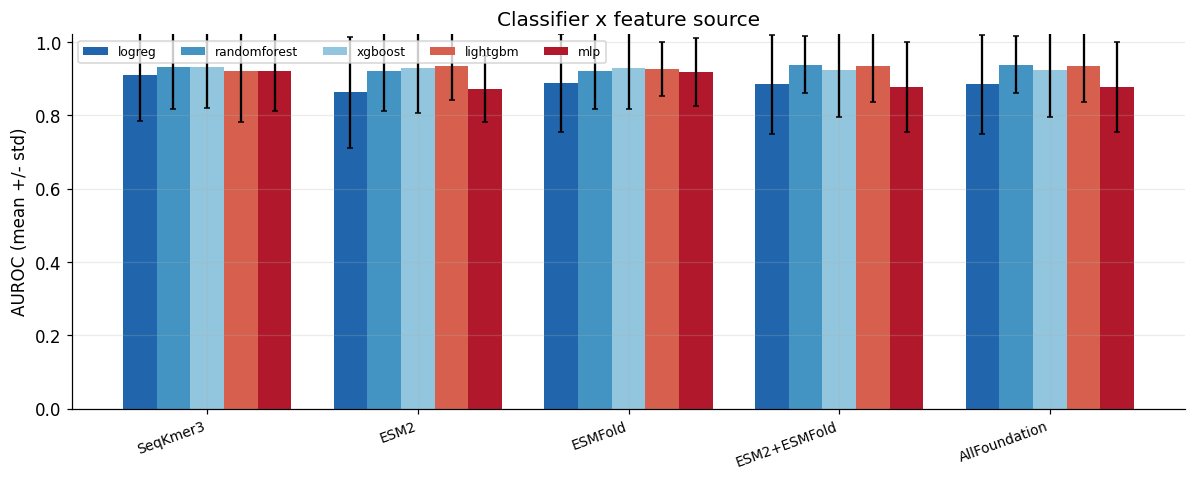

In [12]:
PAL=["#2166AC","#4393C3","#92C5DE","#D6604D","#B2182B","#F4A582","#66BD63"]
fig, ax = plt.subplots(figsize=(11,4.5))
srcs=list(dict.fromkeys(grid["features"])); clfs=list(dict.fromkeys(grid["classifier"]))
x=np.arange(len(srcs)); w=0.8/max(len(clfs),1)
for i,c in enumerate(clfs):
    sub=grid[grid.classifier==c].set_index("features").reindex(srcs)
    ax.bar(x+(i-(len(clfs)-1)/2)*w, sub["AUROC_mean"], w, yerr=sub["AUROC_std"], capsize=2, label=c, color=PAL[i%len(PAL)])
ax.set_xticks(x); ax.set_xticklabels(srcs, rotation=20, ha="right", fontsize=9); ax.set_ylim(0,1.02)
ax.set_ylabel("AUROC (mean +/- std)"); ax.set_title("Classifier x feature source"); ax.legend(ncol=len(clfs), fontsize=8)
plt.tight_layout(); plt.savefig("fig_grid_auroc.png"); plt.show()

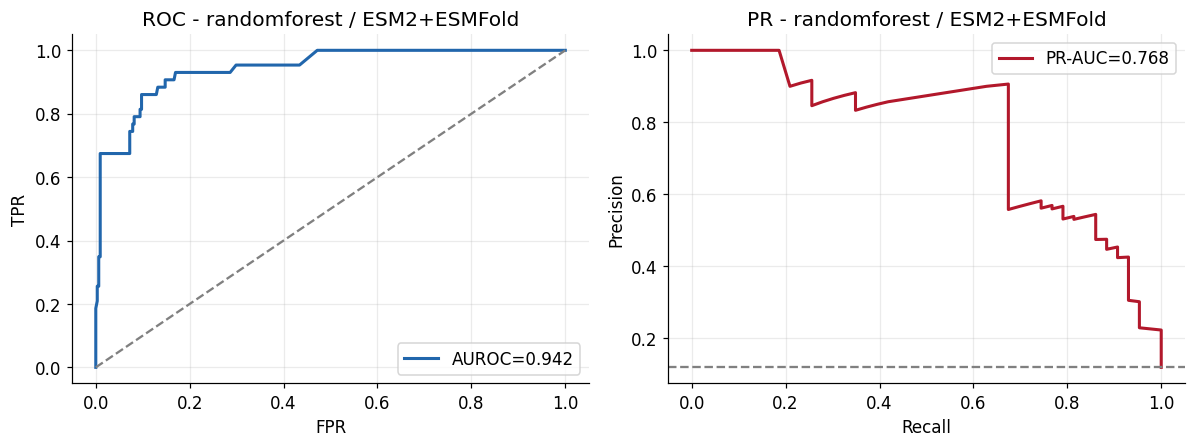

In [13]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
best=max(store, key=lambda k: store[k]["metrics_oof"]["auroc_macro"])
rb=store[best]; y=np.asarray(rb["oof_true"]).astype(int); p=rb["oof_proba"][:,1]
fig, ax = plt.subplots(1,2, figsize=(11,4.2))
fpr,tpr,_=roc_curve(y,p); ax[0].plot(fpr,tpr,lw=2,color="#2166AC",label=f"AUROC={auc(fpr,tpr):.3f}"); ax[0].plot([0,1],[0,1],"--",c="grey"); ax[0].legend(); ax[0].set_title(f"ROC - {best[1]} / {best[0]}"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
pr,rc,_=precision_recall_curve(y,p); ax[1].plot(rc,pr,lw=2,color="#B2182B",label=f"PR-AUC={auc(rc,pr):.3f}"); ax[1].axhline(y.mean(),ls="--",c="grey"); ax[1].legend(); ax[1].set_title(f"PR - {best[1]} / {best[0]}"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
plt.tight_layout(); plt.savefig("fig_grid_best_curves.png"); plt.show()

## 9. Explainable AI - attribution for every model

In [14]:
# SHAP for tree models, coefficients for logistic, permutation importance for MLP.
xai, xai_store = H.explain_grid(cohR, sources, GRID_CLASSIFIERS, top_k=15, n_repeats=5)
xai.to_csv("explanations.csv", index=False)
print("explainer used per classifier:", xai.groupby("classifier")["method"].first().to_dict())
best = max(store, key=lambda k: store[k]["metrics_oof"]["auroc_macro"])
print("best model:", best)
xai[(xai.features==best[0]) & (xai.classifier==best[1])][["feature","importance","method"]].round(4)

explainer used per classifier: {'lightgbm': 'shap_tree', 'logreg': 'coef', 'mlp': 'permutation', 'randomforest': 'shap_tree', 'xgboost': 'shap_tree'}
best model: ('ESM2+ESMFold', 'randomforest')


,feature,importance,method
240,esm2_1158,0.0098,shap_tree
241,esm2_696,0.0057,shap_tree
242,esmf_ss_801,0.0056,shap_tree
243,esm2_883,0.0054,shap_tree
244,esm2_319,0.0050,shap_tree
245,esmf_ss_377,0.0049,shap_tree
246,esm2_194,0.0047,shap_tree
247,esm2_1243,0.0043,shap_tree
248,esm2_69,0.0043,shap_tree
249,esmf_ss_589,0.0041,shap_tree


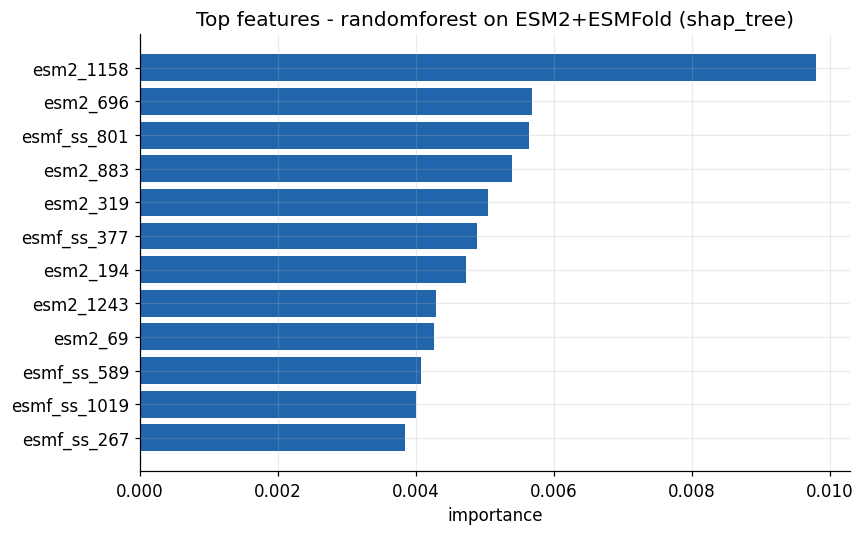

In [15]:
# top features of the best model
sub = xai[(xai.features==best[0]) & (xai.classifier==best[1])].head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(sub["feature"].astype(str), sub["importance"], color="#2166AC")
ax.set_title(f"Top features - {best[1]} on {best[0]} ({sub['method'].iloc[0]})"); ax.set_xlabel("importance")
plt.tight_layout(); plt.savefig("fig_xai_top.png"); plt.show()

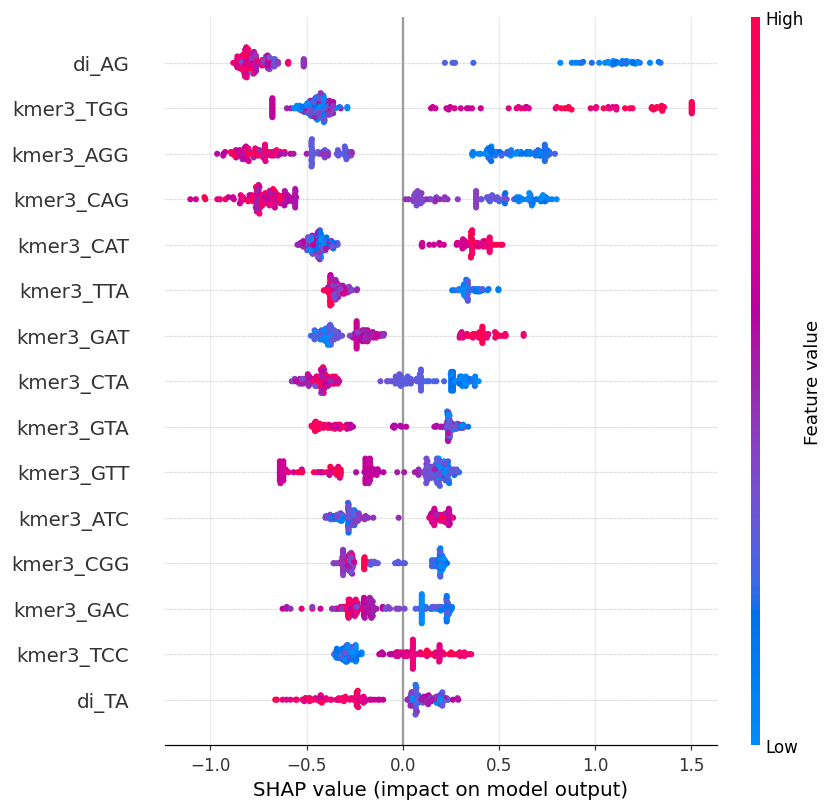

In [16]:
# SHAP beeswarm on the interpretable sequence source (k-mer motifs)
import shap
key = ("SeqKmer3","xgboost")
if key in xai_store and xai_store[key]["shap_summary"] is not None:
    expl, sv, Xsub = xai_store[key]["shap_summary"]
    shap.summary_plot(sv, Xsub, max_display=15, show=False)
    plt.tight_layout(); plt.savefig("fig_xai_shap_seqkmer3.png"); plt.show()
else:
    print("SHAP summary unavailable for SeqKmer3/xgboost in this run")

On **SeqKmer3** the attributions are real k-mer / dinucleotide motifs, so they
read as sequence signal. On **ESM-2 / ESMFold / ColabFold** sources the features are
latent dimensions: the importances show which embedding components drive the call,
not a directly interpretable motif. `explanations.csv` holds the top features for
every (feature source x classifier) pair.

## 10. Explainability for the structural / embedding models (ESM-2 / ESMFold / ColabFold)

In [17]:
# ESMFold & ColabFold: SHAP on NAMED structural features (pLDDT, Ca geometry,
# pLDDT-at-RAS-position) - directly interpretable, unlike latent dims.
struct_xai = {}
for src in ["ESMFold","ColabFold"]:
    if src in sources:
        res = H.explain_structural_features(cohR, sources[src], clf_kind="xgboost", top_k=12)
        if res is not None:
            struct_xai[src] = res
            print(f"{src} top named-structural features:")
            print(res["top"][["feature", res["sort_col"]]].round(4).to_string(index=False))
if not struct_xai:
    print("No structural sources present - run on GPU with RUN_ESMFOLD / ColabFold.")

ESMFold top named-structural features:
   feature  mean_abs_shap
plddt_mean         1.8504
   ca_mean         1.2667
 plddt_min         0.8851
    ca_max         0.5067
    ca_min         0.4928
 ca_median         0.3379
 plddt_std         0.3176
    ca_std         0.3002


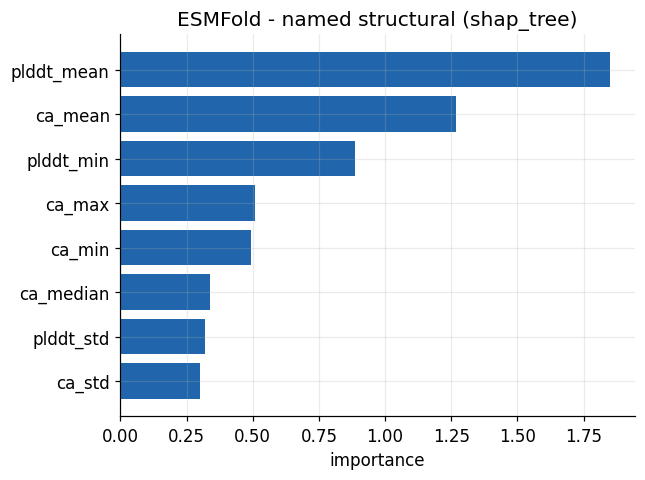

In [18]:
if struct_xai:
    fig, axes = plt.subplots(1, len(struct_xai), figsize=(6*len(struct_xai),4.5), squeeze=False)
    for ax,(src,res) in zip(axes[0], struct_xai.items()):
        sub=res["top"].head(10).iloc[::-1]
        ax.barh(sub["feature"].astype(str), sub[res["sort_col"]], color="#2166AC")
        ax.set_title(f"{src} - named structural ({res['method']})"); ax.set_xlabel("importance")
    plt.tight_layout(); plt.savefig("fig_xai_structural.png"); plt.show()

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: esm2_ft
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


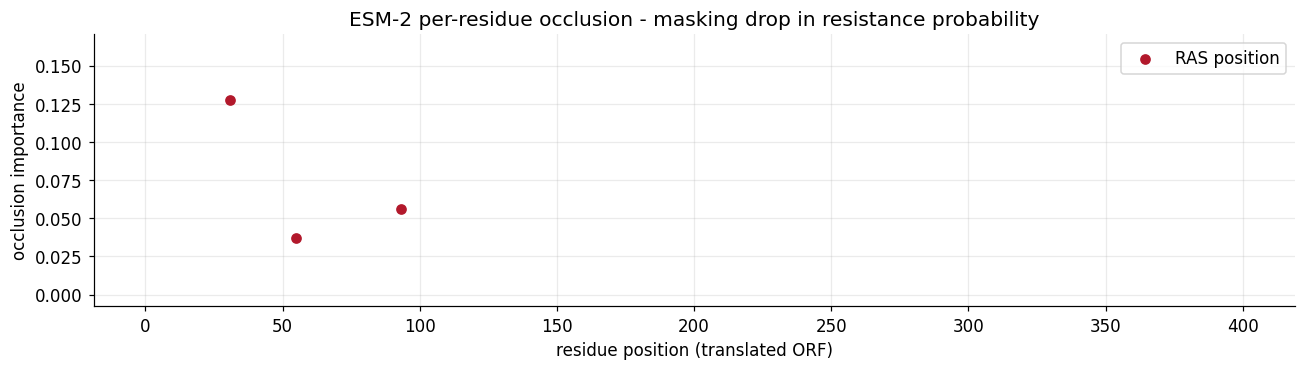

In [19]:
# ESM-2 per-residue occlusion -> which positions drive the resistance call
if "ESM2" in sources and has_gpu():
    try:
        res_e = H.explain_model(cohR, sources["ESM2"], "xgboost")
        prof = H.explain_esm2_positions(cohR, res_e["clf"], res_e["scaler"],
                                        model_name=ESM2_MODEL, sample_n=15, stride=2)
        prof.to_csv("esm2_position_importance.csv", index=False)
        fig, ax = plt.subplots(figsize=(12,3.5))
        ax.plot(prof["position"], prof["importance"], color="#4393C3", lw=1)
        ras = prof[prof["is_ras"]]
        ax.scatter(ras["position"], ras["importance"], color="#B2182B", zorder=5, label="RAS position")
        ax.set_xlabel("residue position (translated ORF)"); ax.set_ylabel("occlusion importance")
        ax.set_title("ESM-2 per-residue occlusion - masking drop in resistance probability"); ax.legend()
        plt.tight_layout(); plt.savefig("fig_xai_esm2_positions.png"); plt.show()
    except Exception as e:
        print("ESM-2 occlusion skipped:", e)
else:
    print("ESM-2 occlusion needs the ESM2 source + GPU.")

**Reading these.** ESMFold/ColabFold named features (e.g. `plddt_ras_93`, mean
pLDDT, Ca geometry) are directly interpretable: they say which structural-confidence
signals move the prediction. The ESM-2 occlusion profile shows which residues, when
masked, most change the resistance call; RAS reference sites are marked in red.
Caveat: positions are indexed on each sequence's translated ORF, so mapping to
canonical H77 RAS numbering requires aligning sequences to a reference first - treat
the overlay as approximate until aligned.

## 11. External validation (hook)

In [ ]:
EXTERNAL_CSV = None
if EXTERNAL_CSV:
    ext = pd.read_csv(EXTERNAL_CSV, low_memory=False)
    cohE = build_cohort(H.add_identity_clusters(H.build_common_cohort(ext, task="binary"), threshold=CLUSTER_TH))
    Xtr = H.features_kmer(cohR, k=3); Xte = H.features_kmer(cohE, k=3)
    from sklearn.preprocessing import StandardScaler
    sc = StandardScaler().fit(Xtr)
    clf = H.make_classifier("xgboost", 2)
    clf.fit(sc.transform(Xtr), cohR.df[cohR.label_col])
    proba = clf.predict_proba(sc.transform(Xte))
    yte = cohE.df[cohE.label_col].to_numpy()
    pred = (proba[:, 1] >= 0.5).astype(int)
    print("External validation:", H.compute_metrics(yte, pred, proba, [0, 1]))
else:
    print("EXTERNAL_CSV not set - provide a held-out Egyptian set to run Experiment 5.")


## 12. Notes
- Cohort = full `hcv_enriched.csv`; every model is evaluated on the same split scheme.
- Labels are Geno2pheno[HCV] silver-standard, not clinical outcomes.
- Saved to /kaggle/working/: grid_results.csv, fig_*.png, cached parquet, esm2_ft/, cf_out/.
